https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [61]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [71]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# training split: 训练模型（权重）
Xtr, Ytr = build_dataset(words[:n1])    
# dev/validation split：超参数
Xdev, Ydev = build_dataset(words[n1:n2])  
# test split：评估模型性能 
Xte, Yte = build_dataset(words[n2:])      


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [145]:
# 构建一个lookup table
embedding_size = 2 # character embedding size
C = torch.randn((27, embedding_size))

In [24]:
# 尝试通过嵌入一个单独的整数（ge. 5），了解lookup table的工作原理
# 下面是做同一件事的两种等效方法，我们采用第一种解释（因为快）。

# 1. 通过lookup table直接查找索引5对应的向量表示
print(C[5])

# 2. one-hot编码后与lookup table相乘，得到索引5对应的向量表示：
#       将其视为整个神经网络中的第一层layer，其权重矩阵为 C。
#       整数编码为 one-hot 后输入到神经网络中，第一层将其嵌入。
print(F.one_hot(torch.tensor(5), num_classes=27).float() @ C) # (27,) @ (27, 2) -> (2,)

tensor([0.8123, 0.0448])
tensor([0.8123, 0.0448])


In [146]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

### 创建第一层

In [147]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [47]:
# 目标是让 emb(n, 3, 2) -> (n, 6)，以便与 W1 相乘

# 方法1：不具备可扩展性，手动拼接
# torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape

# 方法2：使用torch.unbind和torch.cat，更加通用
# torch.unbind(emb, dim=1) # 移除第1维，得到3个(n, 2)的tensor
torch.cat(torch.unbind(emb, dim=1), 1).shape # 在第1维拼接，得到(n, 6)

# 方法3：使用view，更加简洁和高效（不会创建新内存）
# emb.view(emb.shape[0], -1).shape
emb.view(-1, 6).shape

torch.Size([228146, 6])

In [ ]:
# tensor及其视图表示的内部机制
# https://blog.ezyang.com/2019/05/pytorch-internals/

# 调用 view 时并没有改变、复制、移动或创建任何内存，只是改变视图的一些内部属性（storage offset, strides, shapes 等)
# 以便将底层存储的一维字节序列视为不同的 n 维数组

# emb.torage()

In [51]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
# 确保广播机制按预期方式进行
# emb.view(-1, 6) @ W1 --> (n, 100)
# b1 --> (100,) -->        (1, 100)

print(h.shape)
h

torch.Size([228146, 100])


tensor([[ 0.9819,  0.0527,  0.9132,  ...,  0.7768,  0.7301, -0.9799],
        [ 0.8863,  0.3493,  0.6006,  ...,  0.7420,  0.4422, -0.9806],
        [ 0.1256, -0.0066,  0.6243,  ..., -0.0527,  0.8135, -0.9766],
        ...,
        [-0.1218, -0.8292, -0.6603,  ...,  0.7678, -0.1383, -0.9912],
        [ 0.8940, -0.8603, -0.0682,  ..., -0.4634, -0.7538, -0.3331],
        [ 0.8804,  0.0667, -0.5248,  ..., -0.9839,  0.9286, -0.9991]])

### 创建第二层

In [53]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [58]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [56]:
counts = logits.exp()

In [60]:
prob = counts / counts.sum(1, keepdims=True)
# print(prob[0].sum()) # should be 1.0
prob.shape

tensor(1.)


torch.Size([228146, 27])

In [69]:
# prob[torch.arange(prob.shape[0]), Y]：取出每个样本的真实类别概率
loss = -prob[torch.arange(prob.shape[0]), Y].log().mean() 
loss

tensor(18.0558)

### 重新梳理

In [ ]:
# ------------ now made respectable :) ---------------

In [73]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [239]:
embedding_size = 10
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, embedding_size), generator=g)  # embedding matrix 一个字符用10维表示
W1 = torch.randn((block_size * embedding_size, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [241]:
print(sum(p.nelement() for p in parameters) )# number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [243]:
# 确立合理的学习率范围大概是（1e-3 到 1e0）
lre = torch.linspace(-3, 0, 1000) # 按指数步进
lrs = 10**lre

In [244]:
lri = []
lossi = []
stepi = []

for i in range(200000):
  
  # minibatch construct
  # 随机生成 32 个训练样本索引（minibatch size 32）
  minibatch_size = 32
  ix = torch.randint(0, Xtr.shape[0], (minibatch_size,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  # h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1) # (32, 200)
  h = torch.tanh(emb.view(minibatch_size, -1) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  # counts = logits.exp()
  # prob = counts / counts.sum(1, keepdims=True)
  # loss = -prob[torch.arange(32, Ytr[ix]).log().mean()]
  loss = F.cross_entropy(logits, Ytr[ix])
  # 有相当多的理由调用 cross_entropy 而不是手动计算 softmax + nll_loss
  #   1. forward pass 更高效：融合算子，少一次中间张量，省内存、速度更快
  #   2. backward pass 更高效：融合实现可复用中间量，简化梯度形式，减少反向开销
  #   3. 数值稳定性更好：避免 softmax 溢出/下溢
  print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  # lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

27.930326461791992
21.408674240112305
22.90794563293457
23.414772033691406
20.21969223022461
22.24032211303711
17.24951171875
17.680110931396484
22.125654220581055
18.23811912536621
17.709474563598633
18.484106063842773
18.19858741760254
19.685871124267578
12.936335563659668
15.911297798156738
14.41552734375
15.618816375732422
14.32214069366455
14.971871376037598
16.301712036132812
14.15590763092041
21.498830795288086
16.684354782104492
14.793374061584473
15.133179664611816
13.187198638916016
16.024227142333984
14.272439002990723
12.314035415649414
12.514894485473633
10.35278034210205
13.259855270385742
11.438718795776367
13.724236488342285
10.916703224182129
10.444607734680176
10.532289505004883
11.246639251708984
9.906940460205078
12.152475357055664
16.122852325439453
14.736019134521484
13.334700584411621
12.210856437683105
8.306681632995605
10.256769180297852
9.706616401672363
10.78550910949707
10.191875457763672
12.09448528289795
11.887778282165527
10.585350036621094
13.29047584533

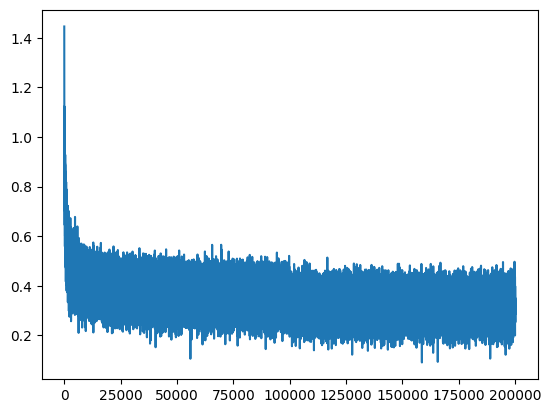

In [258]:
# plt.plot(lri, lossi)
plt.plot(stepi, lossi)

In [259]:
emb = C[Xtr] # (.., 3, 2)
h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1) # (.., 100)
logits = h @ W2 + b2 # (.., 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1226, grad_fn=<NllLossBackward0>)

In [260]:
emb = C[Xdev] # (.., 3, 2)
h = torch.tanh(emb.view(-1, block_size * embedding_size) @ W1 + b1) # (.., 100)
logits = h @ W2 + b2 # (.., 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1612, grad_fn=<NllLossBackward0>)

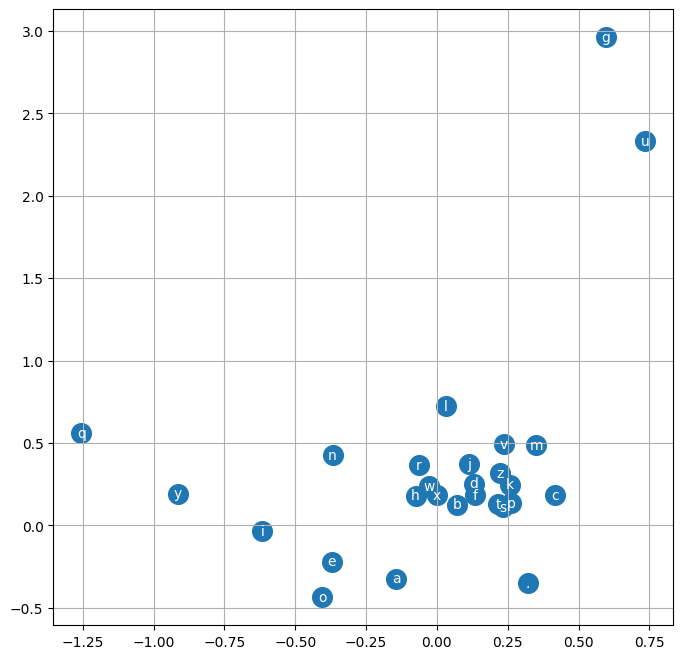

In [208]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [245]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

mora.
mayah.
seel.
nihayla.
rethrettadrie.
cadelyn.
eliighlynne.
leigh.
vananarielle.
malyan.
noshurvon.
hiriel.
kin.
renlynn.
nochlfiu.
zayveer.
yadul.
eli.
kayshia.
kyla.
